In [1]:
# Read in your .xlsx (Excel) file
input_xlsx_file="Ukraine Speeches.xlsx"

In [2]:
# ============================================================
# Installs
# ============================================================
import sys
#!{sys.executable} -m pip install -U pandas openpyxl numpy scipy scikit-learn hdbscan sentence-transformers matplotlib umap-learn

In [3]:
# ============================================================
# Imports
# ============================================================
import re
import unicodedata
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA

import hdbscan
from sentence_transformers import SentenceTransformer

C:\Users\oliver20\SPEECHES\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ============================================================
# Settings
# ============================================================
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 180)
np.set_printoptions(suppress=True)

FILE_PATH = Path(input_xlsx_file)
SHEET_NAME = 0  # change if needed

# Adjust for English vs mixed-language corpora.
USE_ENGLISH_STOP_WORDS = True # Options: 'True','False'
STOP_WORDS = "english" if USE_ENGLISH_STOP_WORDS else None

RANDOM_STATE = 42
MIN_CLUSTER_SIZE = 5  # Good starting point; increase for fewer/larger clusters
TOP_TERMS = 5
# MODEL_NAME = "sentence-transformers/all-mpnet-base-v2" # Solid starting model; if you have higher computation power, try "sentence-transformers/all-MiniLM-L6-v2"

In [5]:
# ============================================================
# Inspect your file
# ============================================================
if not FILE_PATH.exists():
    raise FileNotFoundError(f"Could not find: {FILE_PATH.resolve()}")

raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, engine="openpyxl")
raw.columns = [str(c).strip() for c in raw.columns]

display(raw.head())
print("Columns:", list(raw.columns))
print("Shape:", raw.shape)

,id,title,date,text
0,626,"We Are Pushing for More Air Defense and F-16 Aircraft for Ukraine, Additional Security Commitments and Decisive Actions by America and Europe – Address by the President",2024-07-09,"Dear Ukrainians!\n\nNow, in Washington.\n\nThe NATO Summit starts today.\n\nWe are pushing for more air defense systems for Ukraine. I am confident it will happen. We are pushi..."
1,627,"We Continue Our Work in Washington, and There Will Be a Decision Regarding the F-16s Very Soon – Address by the President",2024-07-10,"I wish you health, fellow Ukrainians!\n\nToday, we continue our work in Washington. Very soon, there will be a decision regarding the F-16s. We are increasing the number of air..."
2,628,"Together with America, the World Is Capable of Doing the Right Things – Speech by Volodymyr Zelenskyy at the Ronald Reagan Presidential Foundation and Institute",2024-07-10,"Thank you very much! Thank you first of all for the invitation!\n\nDear ladies and gentlemen,\n\nMr. Ryan, thank you for the kind introduction,\n\nMr. McConnell, I am grateful ..."
3,629,I Invite You to Build People-to-People Connections That Will Last Forever – Speech by the President of Ukraine at the Meeting of the US National Governors Association,2024-07-12,"Governor Cox,\n\nEsteemed Governors and all present here,\n\nFirst of all thank you very much for the invitation and thank you to all who really cares about protecting life.\n\..."
4,630,We Are Working to Increase the Strength and Number of Ukrainian “Patriots” – Address by the President,2024-07-14,"I wish you health, fellow Ukrainians!\n\nSunday. Morning. The whole week was full of events and negotiations.\n\nNow, after the visit to the United States, there are decisions ..."


Columns: ['id', 'title', 'date', 'text']
Shape: (345, 4)


In [6]:
# ============================================================
# Light cleaning and text-column detection
# ============================================================
def pick_text_column(df: pd.DataFrame) -> str:
    """
    Heuristic text-column picker.
    Tries common names first, then falls back to the object column
    with the longest average string length.
    """
    preferred_keywords = [
        "speech", "text", "content", "transcript", "body", "remarks", "statement", "address", "message"
    ]
    lower_map = {c: str(c).lower() for c in df.columns}

    for keyword in preferred_keywords:
        for col, lower_name in lower_map.items():
            if keyword in lower_name:
                return col

    object_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
    if not object_cols:
        raise ValueError("No likely text column found. Please set the column manually.")

    avg_lengths = {
        col: df[col].astype(str).fillna("").str.len().mean()
        for col in object_cols
    }
    return max(avg_lengths, key=avg_lengths.get)


def clean_text(text) -> str:
    """
    Light, safe cleaning:
    - handles missing values
    - normalizes Unicode
    - removes URLs and HTML
    - collapses whitespace
    """
    if pd.isna(text):
        return ""

    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"<[^>]+>", " ", text)                  # HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)         # URLs
    text = re.sub(r"\s+", " ", text).strip()
    return text


text_col = pick_text_column(raw)
print("Selected text column:", text_col)

df = raw.copy()
df = df.rename(columns={text_col: "text"})
df["text"] = df["text"].map(clean_text)

# For light cleaning: remove empty rows, and deduplicate exact duplicates.
df = df[df["text"].str.len() >= 20].copy()
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

display(df.head())
print("Cleaned shape:", df.shape)

Selected text column: text


,id,title,date,text
0,626,"We Are Pushing for More Air Defense and F-16 Aircraft for Ukraine, Additional Security Commitments and Decisive Actions by America and Europe – Address by the President",2024-07-09,"Dear Ukrainians! Now, in Washington. The NATO Summit starts today. We are pushing for more air defense systems for Ukraine. I am confident it will happen. We are pushing for mo..."
1,627,"We Continue Our Work in Washington, and There Will Be a Decision Regarding the F-16s Very Soon – Address by the President",2024-07-10,"I wish you health, fellow Ukrainians! Today, we continue our work in Washington. Very soon, there will be a decision regarding the F-16s. We are increasing the number of aircra..."
2,628,"Together with America, the World Is Capable of Doing the Right Things – Speech by Volodymyr Zelenskyy at the Ronald Reagan Presidential Foundation and Institute",2024-07-10,"Thank you very much! Thank you first of all for the invitation! Dear ladies and gentlemen, Mr. Ryan, thank you for the kind introduction, Mr. McConnell, I am grateful for your ..."
3,629,I Invite You to Build People-to-People Connections That Will Last Forever – Speech by the President of Ukraine at the Meeting of the US National Governors Association,2024-07-12,"Governor Cox, Esteemed Governors and all present here, First of all thank you very much for the invitation and thank you to all who really cares about protecting life. These da..."
4,630,We Are Working to Increase the Strength and Number of Ukrainian “Patriots” – Address by the President,2024-07-14,"I wish you health, fellow Ukrainians! Sunday. Morning. The whole week was full of events and negotiations. Now, after the visit to the United States, there are decisions regard..."


Cleaned shape: (345, 4)


In [7]:
# ============================================================
# Shared helpers
# ============================================================
def top_terms_for_texts(texts, n=6, stop_words=None):
    """
    Machine-assisted cluster naming:
    fit a small TF-IDF model within the cluster and return the strongest terms.
    """
    texts = [t for t in texts if isinstance(t, str) and t.strip()]
    if not texts:
        return "no text"

    try:
        vec = TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            stop_words=stop_words,
            max_df=0.90,
            min_df=1,
            sublinear_tf=True,
        )
        X = vec.fit_transform(texts)
        scores = np.asarray(X.sum(axis=0)).ravel()
        terms = np.array(vec.get_feature_names_out())

        order = scores.argsort()[::-1]
        chosen = []
        for idx in order:
            term = terms[idx]
            if term not in chosen:
                chosen.append(term)
            if len(chosen) == n:
                break

        return ", ".join(chosen) if chosen else "mixed / weak signal"

    except ValueError:
        # Happens when a tiny cluster has too few distinct terms after filtering.
        fallback = Counter(" ".join(texts).split()).most_common(n)
        return ", ".join([w for w, _ in fallback]) if fallback else "mixed / weak signal"


def build_cluster_summary(result_df, text_col="text", label_col="cluster", prob_col="probability", top_n=6):
    """
    Create a learner-friendly cluster summary:
    - cluster id
    - machine-assisted name
    - size
    - mean membership probability
    - one representative example
    """
    rows = []

    for label in sorted(result_df[label_col].unique()):
        sub = result_df[result_df[label_col] == label].copy()

        if label == -1:
            name = "Noise / unassigned"
        else:
            # Keep stop words None for mixed-language safety.
            name = top_terms_for_texts(sub[text_col].tolist(), n=top_n, stop_words=STOP_WORDS)

        exemplar_row = sub.sort_values(prob_col, ascending=False).iloc[0]
        exemplar_text = exemplar_row[text_col]
        snippet = exemplar_text[:220] + ("..." if len(exemplar_text) > 220 else "")

        rows.append(
            {
                "cluster": label,
                "cluster_name": name,
                "n_docs": len(sub),
                "mean_probability": float(sub[prob_col].mean()),
                "representative_text": snippet,
            }
        )

    summary = pd.DataFrame(rows).sort_values(["cluster"]).reset_index(drop=True)
    return summary


def run_hdbscan_pipeline(features, docs_df, min_cluster_size=10, metric="euclidean"):
    """
    Fit HDBSCAN and return:
    - fitted clusterer
    - dataframe with assigned cluster labels and probabilities
    - cluster summary with machine-assisted names
    """
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=None,
        metric=metric,
        cluster_selection_method="eom",
        prediction_data=True,
        core_dist_n_jobs=-1,
    )

    labels = clusterer.fit_predict(features)

    result_df = docs_df.copy().reset_index(drop=True)
    result_df["cluster"] = labels
    result_df["probability"] = clusterer.probabilities_

    summary = build_cluster_summary(
        result_df,
        text_col="text",
        label_col="cluster",
        prob_col="probability",
        top_n=TOP_TERMS,
    )

    cluster_name_map = dict(zip(summary["cluster"], summary["cluster_name"]))
    result_df["cluster_name"] = result_df["cluster"].map(cluster_name_map)

    return clusterer, result_df, summary


def pipeline_stats(result_df, pipeline_name):
    clustered = result_df["cluster"] != -1
    n_total = len(result_df)
    n_noise = int((~clustered).sum())
    n_clusters = result_df.loc[clustered, "cluster"].nunique()

    mean_prob = result_df.loc[clustered, "probability"].mean() if n_clusters > 0 else np.nan

    return {
        "pipeline": pipeline_name,
        "documents": n_total,
        "clusters": int(n_clusters),
        "noise_docs": n_noise,
        "noise_pct": round(100 * n_noise / n_total, 1) if n_total else np.nan,
        "avg_probability_non_noise": round(float(mean_prob), 3) if pd.notna(mean_prob) else np.nan,
    }


def plot_2d(features, labels, title):
    """
    Simple 2D view for teaching.
    Uses TruncatedSVD for sparse matrices and PCA for dense matrices.
    """
    if sparse.issparse(features):
        reducer = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
        coords = reducer.fit_transform(features)
    else:
        reducer = PCA(n_components=2, random_state=RANDOM_STATE)
        coords = reducer.fit_transform(features)

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=labels, s=18, alpha=0.85, cmap="tab20")
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    plt.tight_layout()
    plt.show()

TF-IDF shape: (345, 4334)
Reduced shape: (345, 100)


,pipeline,documents,clusters,noise_docs,noise_pct,avg_probability_non_noise
0,TF-IDF + SVD,345,3,294,85.2,0.976


,cluster,cluster_name,n_docs,mean_probability,representative_text
0,-1,Noise / unassigned,294,0.000000,"Dear Ukrainians! Now, in Washington. The NATO Summit starts today. We are pushing for more air defense systems for Ukraine. I am confident it will happen. We are pushing for mo..."
1,0,"war, strikes, rescuers, russia, air",9,0.989161,"Dear Ukrainians! Our priority remains the maximum strengthening of Ukraine's air shield. Our air defense, our combat aviation. Every night and every day during this war, Ukrain..."
2,1,"europe, defense, need, security, partners",35,0.968549,"First, I want to thank the Prime Minister of Iceland for hosting this Summit. Thank you so much for the invitation. The Fourth Ukraine – Nordic Countries Meeting in such a form..."
3,2,"world, day, russia, war, independence",7,0.997758,"On July 8, a Russian missile struck Kyiv. A direct hit. The Kh-101 cruise missile. It was designed to hit significant military targets. Putin hit a children's hospital with it...."


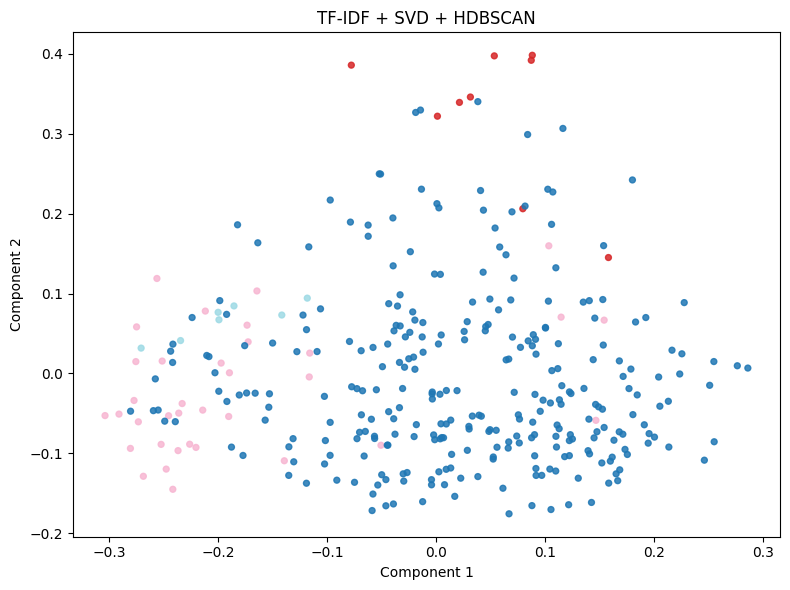

In [8]:
# ============================================================
# Pipeline 1: lexical/statistical 
# TF-IDF -> SVD -> HDBSCAN
# ============================================================
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    ngram_range=(1, 2), # <---- ADJUSTMENT ZONE (try a different n-grams setting)
    max_df=0.85, # <---- ADJUSTMENT ZONE (try different document frequencies -- decimals for percentages or integers for raw numbers)
    min_df=5,
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    sublinear_tf=True,
    stop_words=STOP_WORDS,
)

X_tfidf = tfidf_vectorizer.fit_transform(df["text"])

# Reduce dimensionality preparatory to HDBSCAN
svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
X_tfidf_reduced = svd.fit_transform(X_tfidf)

print("TF-IDF shape:", X_tfidf.shape)
print("Reduced shape:", X_tfidf_reduced.shape)

tfidf_clusterer, tfidf_result, tfidf_summary = run_hdbscan_pipeline(
    features=X_tfidf_reduced,
    docs_df=df,
    min_cluster_size=MIN_CLUSTER_SIZE,
    metric="euclidean",
)

display(pd.DataFrame([pipeline_stats(tfidf_result, "TF-IDF + SVD")]))
display(tfidf_summary)

plot_2d(X_tfidf_reduced, tfidf_result["cluster"].to_numpy(), "TF-IDF + SVD + HDBSCAN")

,pipeline,documents,clusters,noise_docs,noise_pct,avg_probability_non_noise
0,TF-IDF + UMAP + HDBSCAN,345,12,115,33.3,0.927


,cluster,cluster_name,n_docs,mean_probability,representative_text
0,-1,Noise / unassigned,115,0.000000,"Governor Cox, Esteemed Governors and all present here, First of all thank you very much for the invitation and thank you to all who really cares about protecting life. These da..."
1,0,"bring, security, partners, home, support",7,0.980687,Dear Ukrainians! Today is already the tenth anniversary of the day when the Russian occupiers destroyed a passenger plane in the Ukrainian skies – flight MH-17. A Malaysian Boe...
2,1,"defense, today, drones, russia, air",7,0.977779,"I wish you good health, fellow Ukrainians! Briefly about this day. First — the defenders of our skies. Last night alone, almost ninety “Shahed” drones were shot down. This is a..."
3,2,"war, defense, spoke, need, russia",7,0.966942,"I wish you health, fellow Ukrainians! Today we are in Ukraine. The reports about the front and the Kursk operation were given by our military. Our guys are holding their ground..."
4,3,"separate, defense, russian, russia, partners",42,0.903368,"I wish you good health, fellow Ukrainians! A few things for today. First – a meeting with the Minister of Defense. About the new defense packages for Ukraine – something we are..."
5,4,"new, russia, sanctions, partners, russian",8,0.958176,Dear Ukrainians! And all our partners! As we come to the end of the week – the week in which Russia took yet another step to expand the war by striking Ukraine with a new missi...
6,5,"russia, sanctions, support, partners, ukrainian",8,0.985675,"I wish you health, fellow Ukrainians! Today, Chancellor Scholz visited Ukraine. We had an extensive discussion – one of the longest bilateral meetings, in a special format, las..."
7,6,"support, thank, security, today, peace",9,0.917221,"I wish you health, fellow Ukrainians! Sunday. Morning. The whole week was full of events and negotiations. Now, after the visit to the United States, there are decisions regard..."
8,7,"russia, people, europe, russian, world",62,0.964569,"On July 8, a Russian missile struck Kyiv. A direct hit. The Kh-101 cruise missile. It was designed to hit significant military targets. Putin hit a children's hospital with it...."
9,8,"ukrainian, defense, support, thank, internal",13,0.973610,"Dear defenders! Dear family members of our warriors, our heroes! Dear foreign guests! Dear generals! Friends of Ukraine! It has already become a very important tradition that, ..."


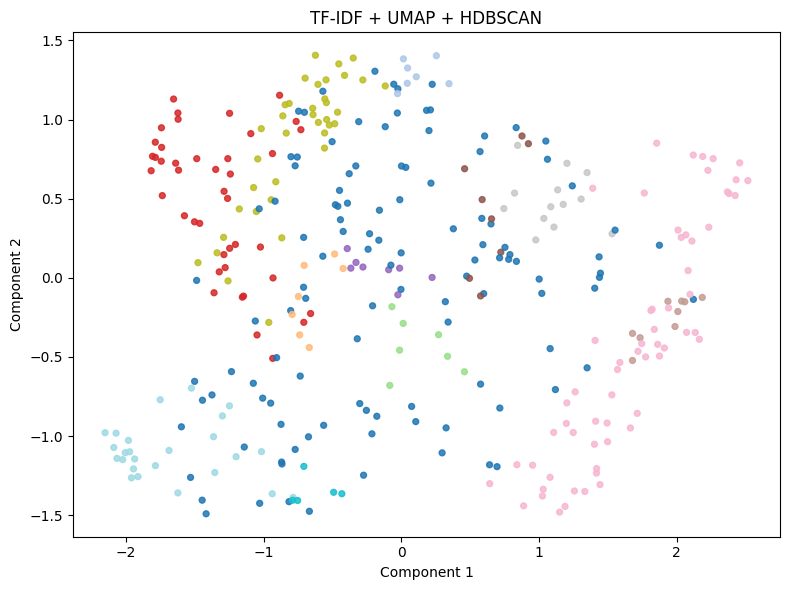

In [9]:
# ============================================================
# Pipeline 2: Semantic preservation of sparse lexical embedding space
# TF-IDF → UMAP → HDBSCAN 
# ============================================================

import umap
from sklearn.feature_extraction.text import TfidfVectorizer
import hdbscan

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=2,
    sublinear_tf=True,
    stop_words=STOP_WORDS,   # or None
)

X_tfidf = tfidf_vectorizer.fit_transform(df["text"])

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    metric="cosine",
    random_state=42,
)

X_tfidf_umap = umap_model.fit_transform(X_tfidf)

tfidf_hdbscan = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    cluster_selection_method="eom",
    metric="euclidean",
    prediction_data=True,
    core_dist_n_jobs=-1,
)

tfidf_labels = tfidf_hdbscan.fit_predict(X_tfidf_umap)

tfidf_a2_result = df.copy().reset_index(drop=True)
tfidf_a2_result["cluster"] = tfidf_labels
tfidf_a2_result["probability"] = tfidf_hdbscan.probabilities_

tfidf_a2_summary = build_cluster_summary(
    tfidf_a2_result,
    text_col="text",
    label_col="cluster",
    prob_col="probability",
    top_n=TOP_TERMS,
)

display(pd.DataFrame([pipeline_stats(tfidf_a2_result, "TF-IDF + UMAP + HDBSCAN")]))
display(tfidf_a2_summary)

plot_2d(X_tfidf_umap, tfidf_a2_result["cluster"].to_numpy(), "TF-IDF + UMAP + HDBSCAN")

Batches: 100%|████████████████████████████████████████████████████████████████████████| 11/11 [46:59<00:00, 256.30s/it]


Embedding shape: (345, 1024)
Reduced shape: (345, 5)


,pipeline,documents,clusters,noise_docs,noise_pct,avg_probability_non_noise
0,e5 + UMAP + HDBSCAN,345,9,100,29.0,0.928


,cluster,cluster_name,n_docs,mean_probability,representative_text
0,-1,Noise / unassigned,100,0.000000,"Dear Ukrainians! Now, in Washington. The NATO Summit starts today. We are pushing for more air defense systems for Ukraine. I am confident it will happen. We are pushing for mo..."
1,0,"day, state, russia, defense, world",15,0.777381,"Ladies and Gentlemen! Everyone in this hall, all our young people watching us, all our Ukrainians – the blossom of our nation. Today is your day, Ukrainian Youth Day. I congrat..."
2,1,"russia, war, captivity, exchange, russian",13,0.899214,"Dear Ukrainians! First of all – our gratitude to our warriors, combat units, which replenish the exchange fund for our state. In different directions. Also, to our special serv..."
3,2,"support, president, partners, people, turkiye",8,0.952287,"I wish you health! Today’s events. A visit from a delegation of the Dutch Parliament. I expressed my gratitude for their support, and we discussed further joint work within the..."
4,3,"peace, support, partners, people, thank",26,0.989205,"I wish you health, fellow Ukrainians! Today, we continue our work in Washington. Very soon, there will be a decision regarding the F-16s. We are increasing the number of aircra..."
5,4,"europe, security, need, world, today",41,0.886027,"Thank you very much! Thank you first of all for the invitation! Dear ladies and gentlemen, Mr. Ryan, thank you for the kind introduction, Mr. McConnell, I am grateful for your ..."
6,5,"today, partners, systems, security, russia",15,0.939458,"Dear Ukrainians! Currently, in the south of our country – in Odesa – rescue efforts continue following the Russian missile strikes. Preliminary, it was ballistics. The strikes ..."
7,6,"war, defense, region, partners, world",54,0.957886,"Dear Ukrainians! The rescue operation in Kostyantynivka, Donetsk region, is still underway after a direct Russian strike on a supermarket. Dozens of other buildings: a post off..."
8,7,"production, drones, russia, russian, ukrainian",20,0.811329,"Dear Ukrainians! Today, I held a meeting of the Staff. Several issues. The first issue is, of course, the front, the report of the Commander-in-Chief – he took part in the meet..."
9,8,"defense, warriors, state, region, people",53,0.985032,"I wish you health, fellow Ukrainians! There have been several important reports today. First of all, there was a substantial report from Commander-in-Chief Syrskyi on the front..."


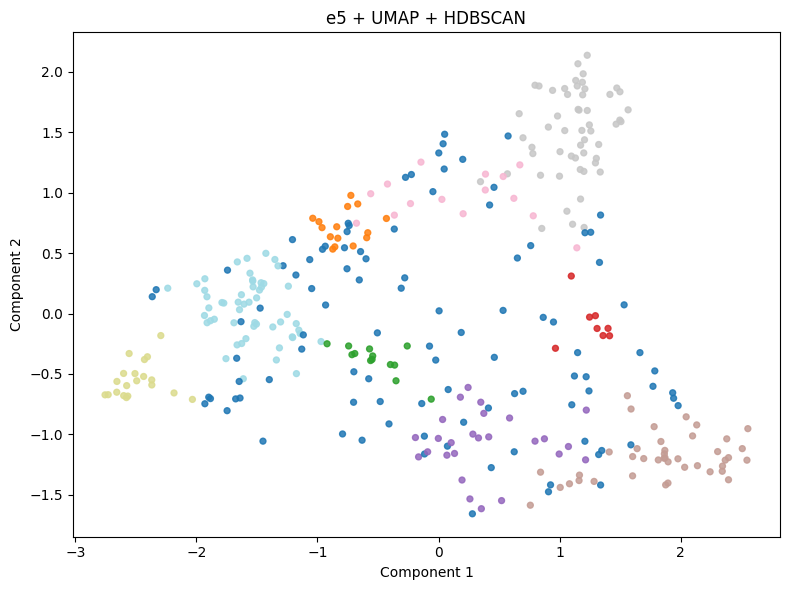

In [10]:
# ============================================================
# Pipeline 3: semantic/embedding using e5 sentence-transformer 
# e5 embeddings → UMAP → HDBSCAN
# ============================================================

import umap

# --- Step 1: Load model ---
model = SentenceTransformer("intfloat/multilingual-e5-large-instruct")

# --- Step 2: Prepare input (important for e5 models) ---
def format_e5_input(texts):
    return [f"passage: {t}" for t in texts]

texts = df["text"].tolist()
formatted_texts = format_e5_input(texts)

# --- Step 3: Generate embeddings ---
embeddings = model.encode(
    formatted_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
)

embeddings = np.asarray(embeddings, dtype=np.float32)

print("Embedding shape:", embeddings.shape)

# --- Step 4: UMAP reduction ---
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    metric="cosine",
    random_state=42,
)

embeddings_reduced = umap_model.fit_transform(embeddings)

print("Reduced shape:", embeddings_reduced.shape)

# --- Step 5: HDBSCAN clustering ---
emb_clusterer, emb_result, emb_summary = run_hdbscan_pipeline(
    features=embeddings_reduced,
    docs_df=df,
    min_cluster_size=MIN_CLUSTER_SIZE,
    metric="euclidean",
)

display(pd.DataFrame([pipeline_stats(emb_result, "e5 + UMAP + HDBSCAN")]))
display(emb_summary)

plot_2d(embeddings_reduced, emb_result["cluster"].to_numpy(), "e5 + UMAP + HDBSCAN")